In [1]:
# 1. Import all the tools we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# 2. Load the Dataset
data = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")

X = data.data

# 0 = No Diabetes, 1 = Diabetes
y = (data.target == "tested_positive").astype(int)
y = pd.Series(y.values, name="target")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())


Features shape: (768, 8)
Target shape: (768,)


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
# 3. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)


Training features: (614, 8)
Testing features : (154, 8)


In [4]:
# 4. Build a Decision Tree for every max_depth value
max_depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]

train_accuracy_results = []
test_accuracy_results = []
precision_results = []
recall_results = []
f1_results = []

for depth in max_depth_values:
    depth_label = "Unrestricted" if depth is None else depth
    print("=" * 60)
    print(f"RESULTS FOR max_depth = {depth_label}")
    print("=" * 60)

    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_model.fit(X_train, y_train)

    train_predictions = tree_model.predict(X_train)
    test_predictions = tree_model.predict(X_test)

    model_train_accuracy = accuracy_score(y_train, train_predictions)
    model_test_accuracy = accuracy_score(y_test, test_predictions)
    model_precision = precision_score(y_test, test_predictions, zero_division=0)
    model_recall = recall_score(y_test, test_predictions, zero_division=0)
    model_f1 = f1_score(y_test, test_predictions, zero_division=0)

    train_accuracy_results.append(model_train_accuracy)
    test_accuracy_results.append(model_test_accuracy)
    precision_results.append(model_precision)
    recall_results.append(model_recall)
    f1_results.append(model_f1)

    print(f"Training Accuracy: {model_train_accuracy:.4f}")
    print(f"Testing Accuracy : {model_test_accuracy:.4f}")
    print(f"Precision        : {model_precision:.4f}")
    print(f"Recall           : {model_recall:.4f}")
    print(f"F1-Score         : {model_f1:.4f}")
    print()

depth_labels = ["Unrestricted" if d is None else d for d in max_depth_values]
results = pd.DataFrame({
    "max_depth": depth_labels,
    "Training Accuracy": train_accuracy_results,
    "Testing Accuracy": test_accuracy_results,
    "Precision": precision_results,
    "Recall": recall_results,
    "F1-Score": f1_results
})

display(results)


RESULTS FOR max_depth = 1
Training Accuracy: 0.7606
Testing Accuracy : 0.6948
Precision        : 0.6522
Recall           : 0.2778
F1-Score         : 0.3896

RESULTS FOR max_depth = 2
Training Accuracy: 0.7638
Testing Accuracy : 0.6948
Precision        : 0.6522
Recall           : 0.2778
F1-Score         : 0.3896

RESULTS FOR max_depth = 3
Training Accuracy: 0.7671
Testing Accuracy : 0.6948
Precision        : 0.6667
Recall           : 0.2593
F1-Score         : 0.3733

RESULTS FOR max_depth = 4
Training Accuracy: 0.7964
Testing Accuracy : 0.7987
Precision        : 0.7447
Recall           : 0.6481
F1-Score         : 0.6931

RESULTS FOR max_depth = 5
Training Accuracy: 0.8241
Testing Accuracy : 0.7922
Precision        : 0.7037
Recall           : 0.7037
F1-Score         : 0.7037

RESULTS FOR max_depth = 6
Training Accuracy: 0.8469
Testing Accuracy : 0.7792
Precision        : 0.6923
Recall           : 0.6667
F1-Score         : 0.6792

RESULTS FOR max_depth = 7
Training Accuracy: 0.8746
Testin

,max_depth,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,1,0.760586,0.694805,0.652174,0.277778,0.389610
1,2,0.763844,0.694805,0.652174,0.277778,0.389610
2,3,0.767101,0.694805,0.666667,0.259259,0.373333
3,4,0.796417,0.798701,0.744681,0.648148,0.693069
4,5,0.824104,0.792208,0.703704,0.703704,0.703704
5,6,0.846906,0.779221,0.692308,0.666667,0.679245
6,7,0.874593,0.766234,0.764706,0.481481,0.590909
7,8,0.913681,0.753247,0.690476,0.537037,0.604167
8,9,0.933225,0.759740,0.688889,0.574074,0.626263
9,10,0.951140,0.733766,0.658537,0.500000,0.568421


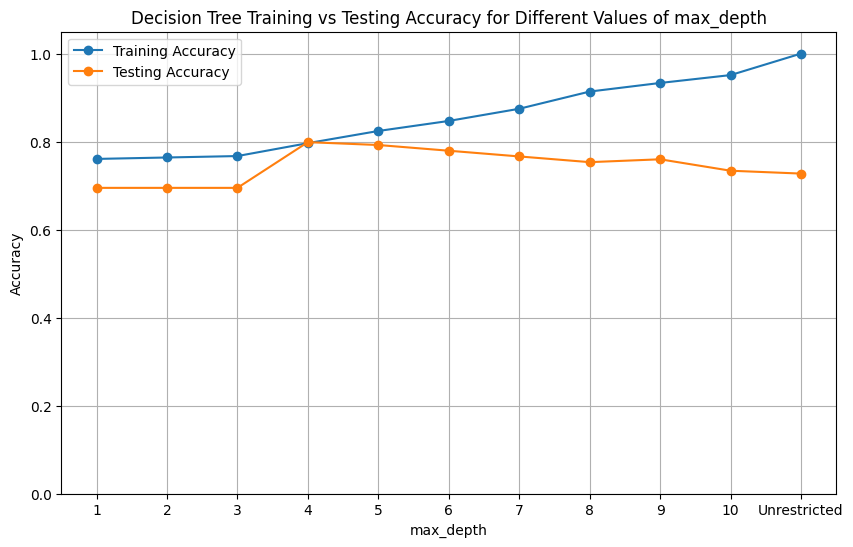

In [5]:
# 5. Plot Training vs Testing Accuracy -- same as class example.
plot_x = list(range(1, len(max_depth_values) + 1))

plt.figure(figsize=(10, 6))
plt.plot(plot_x, train_accuracy_results, marker="o", label="Training Accuracy")
plt.plot(plot_x, test_accuracy_results, marker="o", label="Testing Accuracy")
plt.title("Decision Tree Training vs Testing Accuracy for Different Values of max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.xticks(plot_x, depth_labels)
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.show()


In [6]:
# 6. Identify the Best-Performing Tree and Where Overfitting Begins
best_index = int(np.argmax(test_accuracy_results))
best_depth = depth_labels[best_index]

print(f"Best-performing tree: max_depth = {best_depth}")
print(f"Training Accuracy: {train_accuracy_results[best_index]:.4f}")
print(f"Testing Accuracy : {test_accuracy_results[best_index]:.4f}")
print(f"F1-Score         : {f1_results[best_index]:.4f}")
print()

train_test_gap = [tr - te for tr, te in zip(train_accuracy_results, test_accuracy_results)]

print("max_depth  | Train Acc | Test Acc | Gap (Train - Test)")
for label, tr, te, gap in zip(depth_labels, train_accuracy_results, test_accuracy_results, train_test_gap):
    print(f"{str(label):>10} | {tr:.4f}    | {te:.4f}   | {gap:.4f}")


Best-performing tree: max_depth = 4
Training Accuracy: 0.7964
Testing Accuracy : 0.7987
F1-Score         : 0.6931

max_depth  | Train Acc | Test Acc | Gap (Train - Test)
         1 | 0.7606    | 0.6948   | 0.0658
         2 | 0.7638    | 0.6948   | 0.0690
         3 | 0.7671    | 0.6948   | 0.0723
         4 | 0.7964    | 0.7987   | -0.0023
         5 | 0.8241    | 0.7922   | 0.0319
         6 | 0.8469    | 0.7792   | 0.0677
         7 | 0.8746    | 0.7662   | 0.1084
         8 | 0.9137    | 0.7532   | 0.1604
         9 | 0.9332    | 0.7597   | 0.1735
        10 | 0.9511    | 0.7338   | 0.2174
Unrestricted | 1.0000    | 0.7273   | 0.2727


Best tree actual depth : 4
Best tree leaf count   : 12


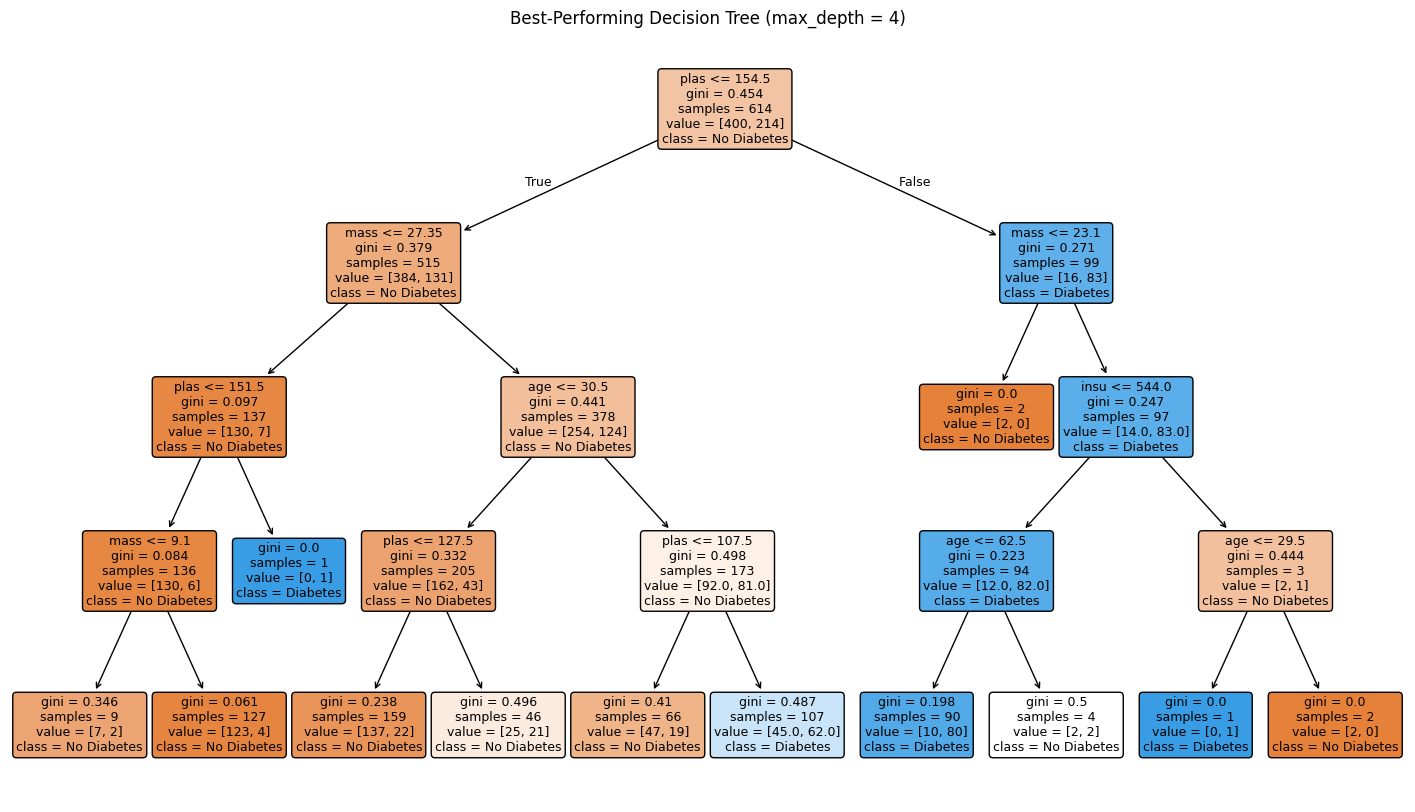

In [7]:
# 7. Visualize the Best-Performing Tree
best_max_depth = None if best_depth == "Unrestricted" else best_depth

best_tree_model = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)
best_tree_model.fit(X_train, y_train)

print("Best tree actual depth :", best_tree_model.get_depth())
print("Best tree leaf count   :", best_tree_model.get_n_leaves())

plt.figure(figsize=(18, 10))
plot_tree(
    best_tree_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,      # Colors the boxes based on the prediction
    rounded=True,     # Rounds the corners of the boxes
    fontsize=9
)
plt.title(f"Best-Performing Decision Tree (max_depth = {best_depth})")
plt.show()


Unrestricted tree actual depth : 16
Unrestricted tree leaf count   : 115


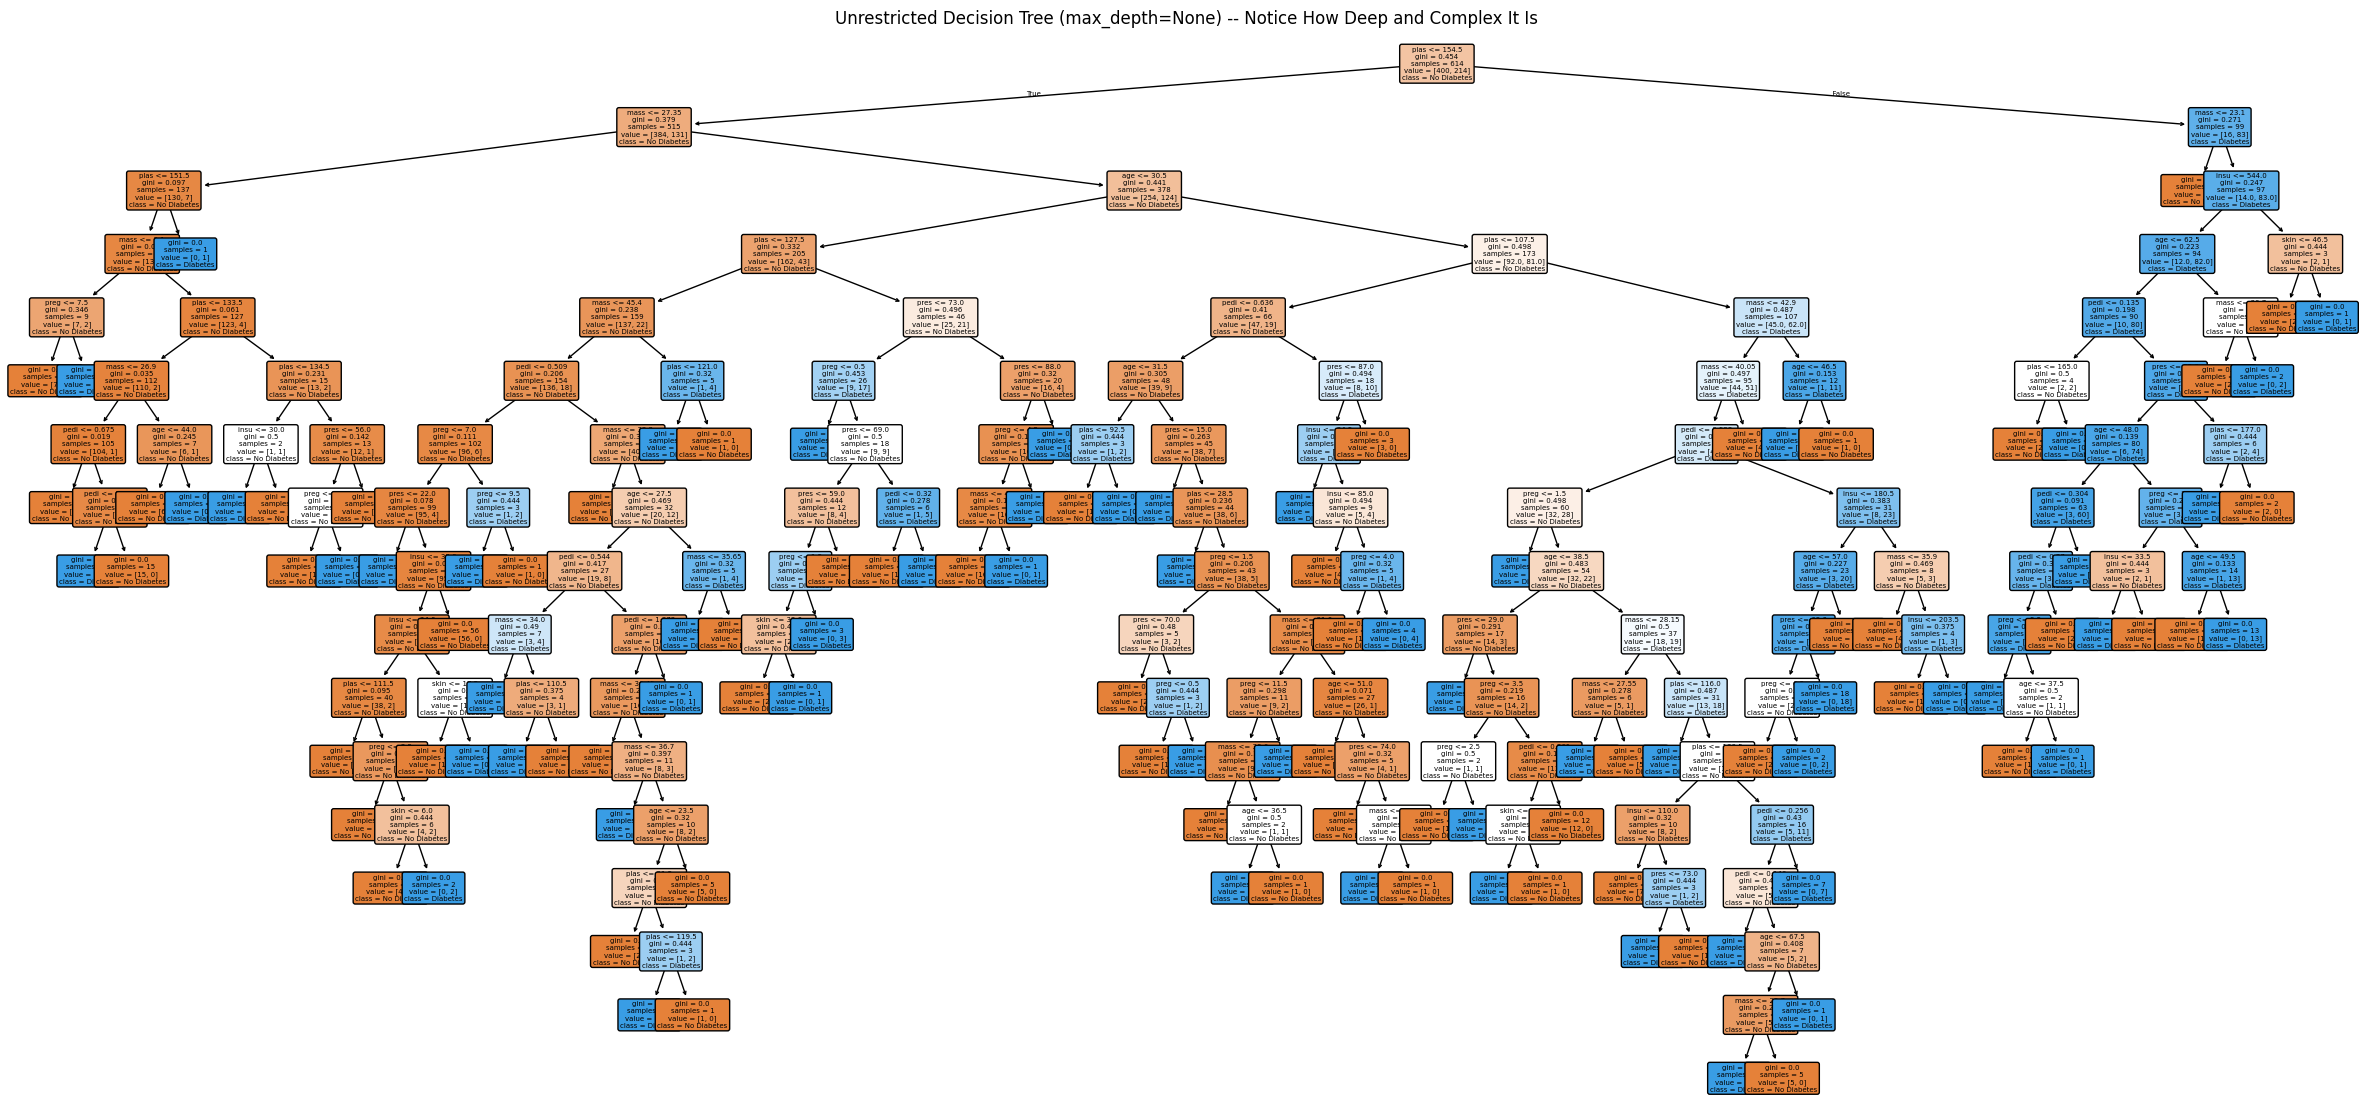

In [8]:
# 8. Visualize the Unrestricted Tree -- to see WHY it overfits
unrestricted_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
unrestricted_tree_model.fit(X_train, y_train)

print("Unrestricted tree actual depth :", unrestricted_tree_model.get_depth())
print("Unrestricted tree leaf count   :", unrestricted_tree_model.get_n_leaves())

plt.figure(figsize=(30, 14))
plot_tree(
    unrestricted_tree_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=5
)
plt.title("Unrestricted Decision Tree (max_depth=None) -- Notice How Deep and Complex It Is")
plt.show()


## Experiment Interpretation

### Where Overfitting Begins
At `max_depth = 1, 2, 3` the tree barely beats guessing the majority class -- Testing Accuracy is
stuck at 69.48% while Training Accuracy only creeps up to 76.71%. This is underfitting: the tree
is too shallow to ask enough questions to separate the two classes. At `max_depth = 4` the tree
finally learns a useful pattern, jumping to **79.87% Testing Accuracy**. From `max_depth = 5`
onward, the story reverses: Training Accuracy keeps climbing all the way to 100% at
`max_depth=None`, but Testing Accuracy **steadily falls** -- 79.22% -> 77.92% -> 76.62% -> 75.32%
-> ... -> 72.73%. This steady divergence between a rising training curve and a falling testing
curve is the signature of overfitting, so **overfitting begins right after `max_depth = 4`**.

### The Best-Performing Tree
**`max_depth = 4`** is the best-performing tree. It produced the highest Testing Accuracy of
every depth tested (79.87%) while Training Accuracy (79.64%) stayed almost identical to it --
the smallest train/test gap of any tree that wasn't underfitting. This is exactly the "sweet
spot" the Training vs. Testing Accuracy plot shows: the two curves are still tracking each other
closely at `max_depth = 4`, right before they start pulling apart.

### Why Unrestricted Trees Can Overfit
With `max_depth=None`, the tree keeps splitting nodes until every leaf is pure (or another
stopping rule like `min_samples_split` kicks in). On this dataset that produced a tree that grew
much deeper and far more complex than the `max_depth = 4` tree, reaching 100% Training Accuracy.
A tree that perfectly explains every training example has stopped learning general rules like
"high glucose is linked to diabetes" and started memorizing individual patients -- including
their noise and outliers. Those hyper-specific rules do not carry over to new data: Testing
Accuracy for the unrestricted tree (72.73%) ends up **worse** than the simple `max_depth = 4`
tree (79.87%), even though the unrestricted tree looks "smarter" on paper with its perfect
training score. This is the same "student who memorizes the practice test but fails the real
exam" problem from the class notes -- without a depth limit, the tree has no reason to stop
asking questions once it can perfectly explain the data in front of it, even when those
questions are meaningless on unseen patients.